# CV d’admission — Albert School
## Du PDF à une synthèse et une note expliquée sur 20

Ce notebook est le **point d’entrée du projet**. Exécuter toutes les cellules dans l’ordre.

1. Lire les PDF et conserver leur texte dans `datas_extract/`.
2. Faire structurer les faits par **Ollama**, puis contrôler le JSON court.
3. Analyser les candidats avec des boucles `for` et des tableaux.
4. Appliquer le barème Python, afficher les points à vérifier et les graphiques.
5. Exporter une synthèse par candidat et comparer aux références.

Les 11 CV du dépôt sont des **CV fictifs de test**. Les JSON livrés dans `sorties/json/`
sont des réponses réellement produites par le modèle, avec leur provenance.
Les exemples manuels réservés aux tests ne sont jamais utilisés comme remplacement.
Le modèle installé fait des erreurs : les corrections issues de la relecture des textes
sont conservées à part dans `sorties/relectures.json`, sans modifier ses réponses originales.

La note est une **proposition pédagogique à relire**, pas une décision d’admission.
Le barème et ses limites sont détaillés dans `grille-notation-cv.md`.

## 1. Configuration
Installer les dépendances du `requirements.txt` à la racine (voir le README),
puis choisir cet environnement Python comme noyau.

Les réponses déjà enregistrées sont réutilisées si le PDF, son texte, le prompt,
le schéma, le nom du modèle et le JSON n’ont pas changé. Cette relecture fonctionne
sans serveur Ollama. Pour un nouveau CV, lancer Ollama avec le modèle indiqué.
`AUTORISER_GENERATION = False` impose une exécution sans nouvel appel au modèle.

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display, Markdown

reperes = [Path.cwd(), *Path.cwd().parents,
           Path.cwd() / "Project_3_Matthieu_Clement_Henry_Ethan_Ilyes"]
RACINE = next((p for p in reperes if (p / "src" / "pipeline.py").is_file()
               and (p / "cv-test").is_dir()), None)
if RACINE is None:
    raise FileNotFoundError("Ouvrir le notebook depuis le dossier du projet.")
sys.path.insert(0, str(RACINE))
from src.pipeline import extrait_pdf, lit_prompt, structure_cv
from src.donnees import valide_cv, valeurs_uniques, mention_standard, nom_competence, applique_relecture
from src.evaluation import CRITERES, evalue_cv, totalise, synthese_markdown

DOSSIER_PDF = RACINE / "cv-test"
DOSSIER_TEXTE = RACINE / "datas_extract"
DOSSIER_SORTIES = RACINE / "sorties"
MODELE = "llama3.2:3b"
ADRESSE_OLLAMA = "http://127.0.0.1:11434"
AUTORISER_GENERATION = False
print(f"Modèle local : {MODELE} | Résultats : {DOSSIER_SORTIES.relative_to(RACINE)}")

Matplotlib is building the font cache; this may take a moment.


Modèle local : llama3.2:3b | Résultats : sorties


## 2. Lire les PDF avec une boucle `for`
À chaque tour, `pdf` désigne un CV. `extrait_pdf` lit la couche texte de toutes
ses pages et conserve un `.txt`. Une page sans texte arrête le traitement :
un PDF scanné demande un OCR et ne doit pas devenir un candidat sans compétences.

Les textes extraits sont les sources de contrôle. Le modèle ne reçoit ni la
note de référence ni le barème de notation.

In [2]:
pdfs = sorted(DOSSIER_PDF.glob("*.pdf"))
if not pdfs:
    raise ValueError(f"Aucun PDF dans {DOSSIER_PDF}.")
entrees = []
bilan_extraction = []
for pdf in pdfs:
    entree = extrait_pdf(pdf, DOSSIER_TEXTE)
    entrees.append(entree)
    bilan_extraction.append({"fichier": pdf.name, "caracteres": len(entree["texte"]),
                             "texte_conserve": str(entree["txt"].relative_to(RACINE))})
display(pd.DataFrame(bilan_extraction))
print(f"{len(entrees)} PDF lus ; textes conservés dans datas_extract/.")

,fichier,caracteres,texte_conserve
0,01_lea_vasseur.pdf,1827,datas_extract/01_lea_vasseur.txt
1,02_nathan_girard.pdf,1557,datas_extract/02_nathan_girard.txt
2,03_camille_roussel.pdf,1413,datas_extract/03_camille_roussel.txt
3,04_hugo_lefebvre.pdf,938,datas_extract/04_hugo_lefebvre.txt
4,05_ines_benali.pdf,778,datas_extract/05_ines_benali.txt
5,06_theo_barbier.pdf,936,datas_extract/06_theo_barbier.txt
6,07_manon_petit.pdf,736,datas_extract/07_manon_petit.txt
7,08_adam_fontaine.pdf,922,datas_extract/08_adam_fontaine.txt
8,09_sarah_da_silva.pdf,937,datas_extract/09_sarah_da_silva.txt
9,10_kevin_dubreuil.pdf,391,datas_extract/10_kevin_dubreuil.txt


11 PDF lus ; textes conservés dans datas_extract/.


## 3. Structurer les faits et contrôler chaque JSON
Ollama organise les informations selon `prompt.md`. Il ne calcule pas la note.
Le schéma limite la réponse aux faits utiles : formation, compétences, langues,
expériences, engagements et séjours.

Le contrôle vérifie les champs et leurs types, les notes scolaires sur 20,
les identifiants et les doublons. **Un format valide ne garantit pas la fidélité
au CV** : consulter les textes et le rapport `sorties/validation.md`.
Le fichier `provenance.json` garde le modèle, la date et les empreintes des sources.
Les corrections de `relectures.json` sont appliquées seulement si leurs empreintes
correspondent et leurs citations existent dans le texte. Une nouvelle réponse
rend l’ancienne relecture périmée : elle doit être vérifiée de nouveau.

In [3]:
prompt = lit_prompt(RACINE / "prompt.md")
candidats = []
origines = {}
identifiants = set()
bilan_relectures = []
for entree in entrees:
    cv, statut = structure_cv(entree, DOSSIER_SORTIES, prompt, modele=MODELE,
                              autoriser_generation=AUTORISER_GENERATION, adresse=ADRESSE_OLLAMA)
    erreurs = valide_cv(cv)
    if erreurs:
        raise ValueError("; ".join(erreurs))
    cv, statut_relecture, corrections = applique_relecture(cv, entree["texte"], DOSSIER_SORTIES)
    identifiant = cv["meta"]["id_candidat"]
    bilan_relectures.append({"id_candidat": identifiant, "relecture": statut_relecture, "champs_corriges": len(corrections)})
    if identifiant in identifiants:
        raise ValueError(f"Candidat en double : {identifiant}")
    identifiants.add(identifiant)
    candidats.append(cv)
    origines[identifiant] = f"Ollama {MODELE} — {statut_relecture}"
    print(f"{identifiant} : {statut} ; {statut_relecture}")
if len(candidats) != len(pdfs):
    raise ValueError("Le nombre de résultats ne correspond pas aux PDF.")
display(pd.DataFrame(bilan_relectures))
print(f"Lot analysé : {len(candidats)} CV — réponses du modèle et relectures tracées.")

01_lea_vasseur : cache modele verifie ; relu avec corrections
02_nathan_girard : cache modele verifie ; relu avec corrections
03_camille_roussel : cache modele verifie ; relu avec corrections
04_hugo_lefebvre : cache modele verifie ; relu avec corrections
05_ines_benali : cache modele verifie ; relu avec corrections
06_theo_barbier : cache modele verifie ; relu avec corrections
07_manon_petit : cache modele verifie ; relu avec corrections
08_adam_fontaine : cache modele verifie ; relu avec corrections
09_sarah_da_silva : cache modele verifie ; relu avec corrections
10_kevin_dubreuil : cache modele verifie ; relu avec corrections
11_chloe_renard : cache modele verifie ; relu avec corrections


,id_candidat,relecture,champs_corriges
0,01_lea_vasseur,relu avec corrections,13
1,02_nathan_girard,relu avec corrections,9
2,03_camille_roussel,relu avec corrections,12
3,04_hugo_lefebvre,relu avec corrections,10
4,05_ines_benali,relu avec corrections,9
5,06_theo_barbier,relu avec corrections,10
6,07_manon_petit,relu avec corrections,9
7,08_adam_fontaine,relu avec corrections,6
8,09_sarah_da_silva,relu avec corrections,7
9,10_kevin_dubreuil,relu avec corrections,9


Lot analysé : 11 CV — réponses du modèle et relectures tracées.


## 4. Calculer les indicateurs en Python
La boucle extérieure parcourt les candidats ; les boucles intérieures comptent
leurs compétences et expériences. Une compétence répétée compte une fois.

**Zéro signifie « aucun élément mentionné ».** `None` signifie que la rubrique
est illisible ou que le type d’expérience est inconnu ; il est exclu des moyennes.
Les fonctions de notation restent dans `src/evaluation.py` : leurs règles sont
écrites une seule fois et testées indépendamment du notebook.

In [4]:
lignes = []
details_notes = []
criteres_par_cv = {}
effectifs_langages = {}
base_competences = 0
for cv in candidats:
    identifiant = cv["meta"]["id_candidat"]
    illisibles = cv["rubriques_illisibles"]
    langages = valeurs_uniques([nom_competence(x) for x in cv["competences"]["langages"]])
    if "competences" not in illisibles:
        base_competences += 1
        for langage in langages:
            effectifs_langages[langage] = effectifs_langages.get(langage, 0) + 1
    nb_stages = 0
    types_connus = True
    for experience in cv["experiences"]:
        if experience["type"] == "stage":
            nb_stages += 1
        if experience["type"] is None:
            types_connus = False
    criteres = evalue_cv(cv)
    note, reserve = totalise(criteres)
    criteres_par_cv[identifiant] = criteres
    details_notes.extend(criteres)
    lignes.append({
        "id_candidat": identifiant, "fichier_source": cv["meta"]["fichier_source"],
        "mention_bac": None if "formation" in illisibles else mention_standard(cv["formation"]["mention_bac"]),
        "nb_langages": None if "competences" in illisibles else len(langages),
        "nb_projets": None if "competences" in illisibles else len(cv["competences"]["projets"]),
        "nb_experiences": None if "experiences" in illisibles else len(cv["experiences"]),
        "nb_stages": nb_stages if types_connus and "experiences" not in illisibles else None,
        "nb_engagements": None if "engagements" in illisibles else len(cv["engagements"]),
        "note_sur20": note, "points_a_verifier": reserve,
        "plafond_apres_verification": round(note + reserve, 2),
        "origine": origines[identifiant],
    })
df = pd.DataFrame(lignes)
df_criteres = pd.DataFrame(details_notes)
display(df[["id_candidat", "mention_bac", "nb_langages", "nb_stages", "note_sur20", "points_a_verifier"]])

,id_candidat,mention_bac,nb_langages,nb_stages,note_sur20,points_a_verifier
0,01_lea_vasseur,tres bien,2,1,18.50,0.0
1,02_nathan_girard,tres bien,2,1,19.00,0.0
2,03_camille_roussel,bien,1,1,17.00,0.0
3,04_hugo_lefebvre,bien,0,1,11.75,1.5
4,05_ines_benali,assez bien,1,0,11.50,1.5
5,06_theo_barbier,bien,0,0,9.75,0.0
6,07_manon_petit,assez bien,3,0,10.50,0.0
7,08_adam_fontaine,bien,0,1,11.75,0.0
8,09_sarah_da_silva,assez bien,0,1,9.25,1.5
9,10_kevin_dubreuil,sans mention,0,0,4.00,1.5


## 5. Comprendre les notes
Les huit poids totalisent **20 points**. `note_sur20` est la somme des points
attribués par les règles. Les points dépendant d’une information manquante sont
signalés dans `points_a_verifier` et **ne sont pas ajoutés** à la note.
On ne ramène jamais une note partielle artificiellement sur 20.

Exemple : `11,75/20`, avec `1,5 point à vérifier`, signifie que la note pourrait
atteindre au maximum `13,25/20` si l’information manquante justifie tous ces points.
Ce maximum n’est pas une prédiction. Les erreurs d’extraction peuvent aussi
modifier les points déjà calculés.

La mention du bac n’est jamais déduite d’une moyenne. Les résultats de matières
et de trimestres sont conservés séparément ; le barème retient un résultat de
maths seulement si son contexte permet un choix explicite.

In [5]:
display(pd.DataFrame([{"critere": nom, "poids": poids} for nom, poids in CRITERES.values()]))
assert sum(poids for _, poids in CRITERES.values()) == 20
resultats_scolaires = []
for cv in candidats:
    for resultat in cv["formation"]["resultats"]:
        resultats_scolaires.append({"id_candidat": cv["meta"]["id_candidat"], **resultat})
display(pd.DataFrame(resultats_scolaires, columns=["id_candidat", "intitule", "note_sur_20"]))
print("Les notes d'admission sont des propositions pédagogiques à valider avec l'équipe.")

,critere,poids
0,Excellence académique,6.0
1,Aptitude quantitative,4.0
2,Compétences data / tech,2.0
3,Anglais et langues,2.0
4,Expérience professionnelle,3.0
5,Engagement et responsabilités,2.0
6,Ouverture internationale,0.5
7,Liens factuels avec Business & Data,0.5


,id_candidat,intitule,note_sur_20
0,01_lea_vasseur,Moyenne générale de Terminale,17.4
1,01_lea_vasseur,Moyenne en mathématiques,18.2
2,02_nathan_girard,Moyenne générale,16.8
3,02_nathan_girard,Mathématiques,16.5
4,03_camille_roussel,Moyenne générale,15.6
5,03_camille_roussel,"Moyenne générale, premier trimestre",14.9
6,03_camille_roussel,"Moyenne générale, troisième trimestre",16.4
7,03_camille_roussel,Mathématiques,16.1
8,04_hugo_lefebvre,Moyenne générale,14.8
9,05_ines_benali,Moyenne générale,13.2


Les notes d'admission sont des propositions pédagogiques à valider avec l'équipe.


## 6. Une synthèse factuelle par candidat
Modifier `CANDIDAT_A_LIRE` pour consulter un autre dossier.
Toutes les synthèses seront exportées à la fin du notebook.
Les faits sont des reformulations du modèle : le lien vers le texte permet de
vérifier notamment les niveaux, les missions, les durées et les informations absentes.

In [6]:
CANDIDAT_A_LIRE = candidats[0]["meta"]["id_candidat"]
cv_selectionne = next(cv for cv in candidats if cv["meta"]["id_candidat"] == CANDIDAT_A_LIRE)
display(Markdown(synthese_markdown(cv_selectionne, criteres_par_cv[CANDIDAT_A_LIRE], origines[CANDIDAT_A_LIRE])))

## 01_lea_vasseur

**Note pédagogique provisoire : 18.5/20. Points restant à vérifier : 0.**
Origine des données : Ollama llama3.2:3b — relu avec corrections. Source : `datas_extract/01_lea_vasseur.txt`.

Les points à vérifier ne sont pas ajoutés à la note ; ils indiquent son incertitude liée aux données.

### Excellence académique — 6/6

Baccalauréat Général; Mention Très Bien; Lycée Henri IV, Paris

Règle : Mention explicite : TB 6 ; B 4,5 ; AB 3,5 ; sans mention 2. Aucun point lié à la réputation du lycée ou au redoublement.
À vérifier : Vérifier la mention sur le justificatif académique.

### Aptitude quantitative — 4/4

Mathématiques; Physique-Chimie; NSI; 2025 - Olympiades Académiques de Mathématiques - Qualifiée pour la seconde phase - académie de Paris; Moyenne générale de Terminale — 17.4; Moyenne en mathématiques — 18.2

Règle : Maths en spécialité +1,5 ; autre spécialité scientifique +0,5 ; concours scientifique +0,5 ; note de maths jusqu'à +1,5.
À vérifier : Moyenne en mathématiques : 18.2/20 retenu.

### Compétences data / tech — 1.75/2

Python — bon niveau (pandas, matplotlib); SQL — requêtes, jointures; pandas; matplotlib; Power BI — tableaux de bord; Excel — avancé (TCD, recherchev); Git; GitHub; StatsLigue1 : scraping et traitement de 5 saisons de statistiques ; visualisations et modèle simple de prédiction ; projet open source, environ 40 étoiles sur GitHub

Règle : Socle 0,5 ; langage +0,5 ; outil data/Excel avancé +0,25 ; projet +0,5 (+0,25 si inachevé) ; certification data obtenue +0,25.
À vérifier : Les niveaux sont déclarés. Contrôler les projets et certificats ; une technologie hors liste demande une revue.

### Anglais et langues — 2/2

Anglais — TOEFL iBT — 112/120; Espagnol — B1

Règle : Anglais jusqu'à 1,5 selon le niveau ou le score explicite ; autre langue mentionnée +0,5.
À vérifier : Barème du projet pour TOEFL iBT 112/120 ; aucune conversion CECRL.

### Expérience professionnelle — 1.75/3

stage — stagiaire Data — Nivo Finance — 2 semaines — Nettoyage et consolidation d'un jeu de données clients (environ 30 000 lignes) sous Python, Construction de deux tableaux de bord Power BI suivis par l'équipe commerciale, Restitution orale des résultats devant 4 collaborateurs

Règle : Socle 0,5 ; première expérience +0,75 ; deuxième +0,75 ; missions décrites +0,5 ; régularité ou durée explicite suffisante +0,5.
À vérifier : Durées conservées telles qu'écrites ; pas de conversion approximative des dates.

### Engagement et responsabilités — 2/2

Vice-présidente — Club Entrepreneuriat du lycée — Organisation de 3 conférences et d’un concours de pitch (environ 80 participants); Escalade — club — 4 ans

Règle : Activité collective +0,5 ; responsabilité explicite +0,75 ; action associée décrite +0,75.
À vérifier : Les loisirs individuels seuls ne constituent pas un engagement collectif.

### Ouverture internationale — 0.5/0.5

Canada — Échange scolaire à Toronto, Northern Secondary School — Un semestre

Règle : Socle 0,25 même sans séjour ; séjour d'études/échange/immersion explicite +0,25. Aucun point pour la nationalité.
À vérifier : Motif du séjour à vérifier s'il est ambigu.

### Liens factuels avec Business & Data — 0.5/0.5

Rubriques avec un lien explicite : formation, competences, experiences

Règle : +0,25 par rubrique reliée à Business & Data, plafond 0,5. Indicateur de liens factuels, sans jugement sur la motivation.
À vérifier : La cohérence du projet personnel reste à discuter avec le candidat.

### Informations manquantes

- Aucune information bloquante identifiée par les règles.

Note indicative à relire avec les pièces du dossier ; aucune décision d'admission automatique.


## 7. Statistiques descriptives et graphiques
Les pourcentages utilisent seulement les CV dont la rubrique est exploitable.
Un langage est compté au plus une fois par candidat. Les barres des notes suivent
l’ordre des fichiers, sans classement automatique d’admission.

,langage,candidats,pourcentage
0,python,5,45.5
1,sql,2,18.2
2,html,1,9.1
3,css,1,9.1


Au moins un stage mentionné : 6/11 CV (54.5 %).
Compétences exploitables : 11/11 CV.


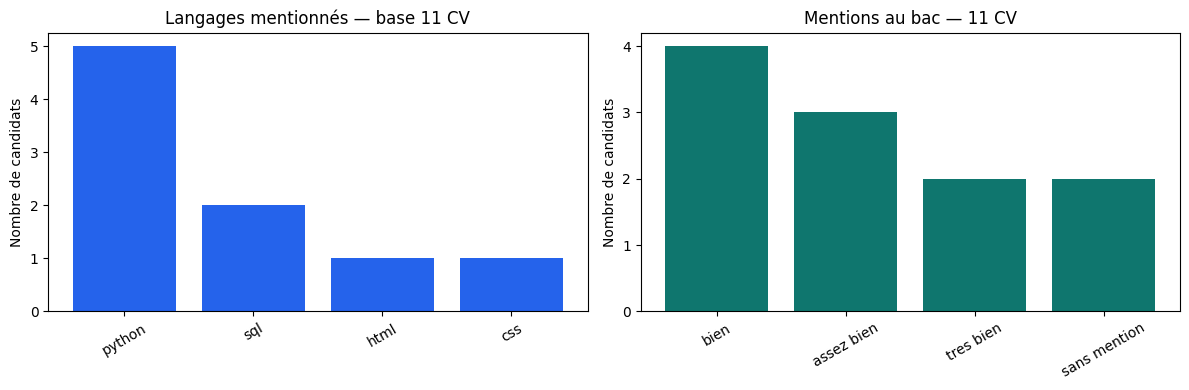

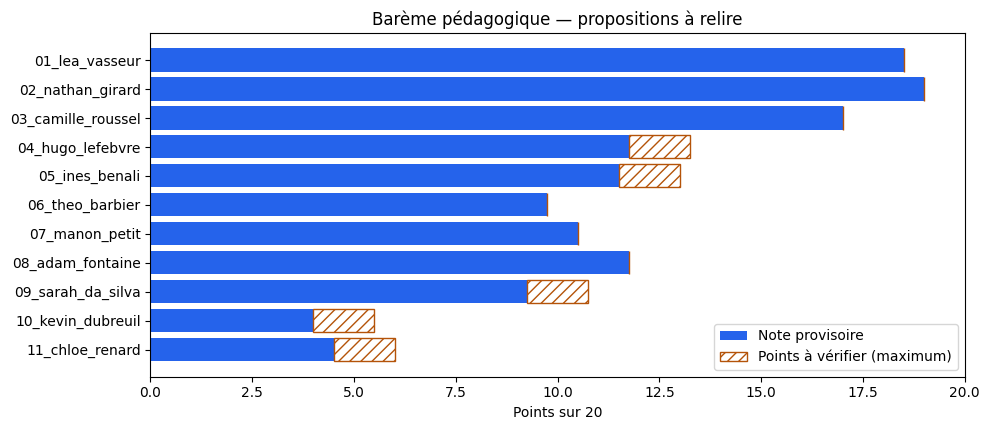

In [7]:
frequences = []
for langage, effectif in effectifs_langages.items():
    frequences.append({"langage": langage, "candidats": effectif,
                       "pourcentage": round(100 * effectif / base_competences, 1)})
df_langages = pd.DataFrame(frequences, columns=["langage", "candidats", "pourcentage"])
df_langages = df_langages.sort_values("candidats", ascending=False)
display(df_langages)
stages_connus = df["nb_stages"].dropna()
avec_stage = 0
for nombre in stages_connus:
    if nombre > 0:
        avec_stage += 1
if len(stages_connus):
    print(f"Au moins un stage mentionné : {avec_stage}/{len(stages_connus)} CV ({100 * avec_stage / len(stages_connus):.1f} %).")
print(f"Compétences exploitables : {base_competences}/{len(candidats)} CV.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if not df_langages.empty:
    axes[0].bar(df_langages["langage"], df_langages["candidats"], color="#2563eb")
else:
    axes[0].text(0.5, 0.5, "Aucun langage exploitable", ha="center")
axes[0].set_title(f"Langages mentionnés — base {base_competences} CV")
mentions = df["mention_bac"].fillna("non renseignée").value_counts()
axes[1].bar(mentions.index, mentions.values, color="#0f766e")
axes[1].set_title(f"Mentions au bac — {len(df)} CV")
for axe in axes:
    axe.set_ylabel("Nombre de candidats")
    axe.yaxis.set_major_locator(MaxNLocator(integer=True))
    axe.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

fig, axe = plt.subplots(figsize=(10, max(4, len(df) * 0.4)))
axe.barh(df["id_candidat"], df["note_sur20"], color="#2563eb", label="Note provisoire")
axe.barh(df["id_candidat"], df["points_a_verifier"], left=df["note_sur20"],
         facecolor="none", edgecolor="#b45309", hatch="///", label="Points à vérifier (maximum)")
axe.invert_yaxis()
axe.set_xlim(0, 20)
axe.set_xlabel("Points sur 20")
axe.set_title("Barème pédagogique — propositions à relire")
axe.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 8. Comparaison aux références du projet
Cette cellule lit les notes de référence **après** la structuration et le calcul.
Elles n’ont été utilisées ni dans le prompt ni dans les règles de notation.

Les écarts comparent deux méthodes différentes. Leur moyenne n’est pas une
mesure de fiabilité de l’extraction, ni une validation du barème d’admission.
La qualité de l’extraction se vérifie en comparant les faits aux textes sources.

In [8]:
chemin_references = DOSSIER_PDF / "notes-reference.csv"
comparaison = pd.DataFrame()
if chemin_references.exists():
    references = pd.read_csv(chemin_references, sep=";")
    comparaison = df[["fichier_source", "id_candidat", "note_sur20", "points_a_verifier"]].merge(
        references[["fichier", "total_sur20"]], left_on="fichier_source", right_on="fichier",
        how="left", validate="one_to_one")
    comparaison = comparaison.rename(columns={"total_sur20": "note_reference"})
    comparaison["ecart"] = comparaison["note_sur20"] - comparaison["note_reference"]
    display(comparaison[["id_candidat", "note_sur20", "points_a_verifier", "note_reference", "ecart"]])
    ecarts = comparaison["ecart"].dropna()
    if len(ecarts):
        print(f"Écart absolu moyen : {ecarts.abs().mean():.2f} point(s), sur {len(ecarts)}/{len(df)} CV appariés.")
else:
    print("Références absentes : comparaison ignorée.")

,id_candidat,note_sur20,points_a_verifier,note_reference,ecart
0,01_lea_vasseur,18.50,0.0,19.0,-0.50
1,02_nathan_girard,19.00,0.0,15.5,3.50
2,03_camille_roussel,17.00,0.0,13.0,4.00
3,04_hugo_lefebvre,11.75,1.5,11.0,0.75
4,05_ines_benali,11.50,1.5,10.5,1.00
5,06_theo_barbier,9.75,0.0,8.0,1.75
6,07_manon_petit,10.50,0.0,8.0,2.50
7,08_adam_fontaine,11.75,0.0,8.5,3.25
8,09_sarah_da_silva,9.25,1.5,9.0,0.25
9,10_kevin_dubreuil,4.00,1.5,4.0,0.00


Écart absolu moyen : 1.68 point(s), sur 11/11 CV appariés.


## 9. Exporter le rendu
`candidats.csv` donne une ligne par candidat ; `criteres.csv` explique les huit
sous-notes ; `syntheses.md` rassemble les synthèses individuelles.
Les résultats sont régénérables. Les JSON et leur provenance restent disponibles
pour relancer l’analyse sans appel au modèle.

In [9]:
DOSSIER_SORTIES.mkdir(parents=True, exist_ok=True)
df.to_csv(DOSSIER_SORTIES / "candidats.csv", index=False)
df_criteres.to_csv(DOSSIER_SORTIES / "criteres.csv", index=False)
if not comparaison.empty:
    comparaison.to_csv(DOSSIER_SORTIES / "comparaison.csv", index=False)
syntheses = ["# Synthèses des CV — propositions pédagogiques", "",
             f"Lot : {len(candidats)} PDF ; données structurées par Ollama {MODELE}.", ""]
for cv in candidats:
    identifiant = cv["meta"]["id_candidat"]
    syntheses.append(synthese_markdown(cv, criteres_par_cv[identifiant], origines[identifiant]))
(DOSSIER_SORTIES / "syntheses.md").write_text("\n".join(syntheses), encoding="utf-8")
print(f"Terminé : {len(candidats)} CV, {len(df_criteres)} critères détaillés, synthèses et CSV dans sorties/.")

Terminé : 11 CV, 88 critères détaillés, synthèses et CSV dans sorties/.


## 10. Conclusion à présenter
- La chaîne complète est rejouable depuis ce notebook.
- Le modèle range les faits ; Python calcule les indicateurs et les points.
- Chaque note possède huit sous-notes, des faits, une règle et des points à vérifier.
- Une absence de mention ne prouve pas une absence de compétence.
- Le barème est une convention pédagogique : les pondérations viennent de la grille,
  les règles détaillées restent à valider par l’équipe et le professeur.
- Les 11 CV fictifs ne permettent pas de démontrer une généralisation à tous les dossiers.
- Relire `sorties/validation.md` pour connaître les contrôles effectués et leurs limites.